![alt text](image.png)

# GIẢI THÍCH CHIẾC MEME "BACKUP TRÊN SERVER"
1. **Nỗi đau (Pain Point)**
- Trong lập trình, server có thể "chết" (crash) bất cứ lúc nào do quá tải, lỗi phần cứng, hoặc hỏa hoạn tại trung tâm dữ liệu.
	+ Khi server sập, toàn bộ dữ liệu đang chạy trong biến (In-memory DB) sẽ bị mất sạch.
	+ Nếu em có lưu dữ liệu vào file vật lý trong thư mục `db/` nhưng thư mục đó lại nằm ngay trên chính cái server đang hỏng kia, thì coi như em "trắng tay".

2. **Giải pháp (Solution)**
- Để tránh "nỗi đau" này, anh em mình phải thực hiện **Off-site Backup**.
	+ Tức là bản sao lưu dữ liệu (Backup) phải được đẩy lên một nơi khác hoàn toàn: Một server khác, Google Drive, hoặc các dịch vụ lưu trữ đám mây như AWS S3...

3. **Khái niệm & Tại sao (ELI5)**
	- Câu hỏi: "Server sập rồi. Bản sao lưu đâu?"
	- Câu trả lời: "Dạ, em để... trên chính cái server vừa sập đó ạ."
	- **Tại sao nó buồn cười (và bi kịch)**: Nó giống như việc em đánh mất chìa khóa nhà, nhưng khi được hỏi "Chìa khóa dự phòng đâu?" thì em trả lời là "Em cất... bên trong nhà rồi". Server đã sập thì em không thể truy cập vào để lấy bản backup đó ra được nữa.

4. **Ẩn dụ (Analogy)**
- Hãy nghĩ về **Liên Quân Mobile**:
	- Nếu toàn bộ lịch sử đấu và trang phục của em chỉ lưu trên bộ nhớ điện thoại (Local).
	- Một ngày đẹp trời điện thoại em bị rơi xuống nước (Server Crash).
	- Em mượn máy khác đăng nhập nhưng mọi thứ biến mất vì "Dữ liệu dự phòng cũng nằm trong cái máy hỏng kia".
	- Thực tế: Garena lưu dữ liệu của em trên hệ thống máy chủ của họ, nên dù em có mất điện thoại thì nick em vẫn còn nguyên. Đó mới là cách làm đúng!

> Lời khuyên: `Đừng bao giờ để "trứng vào cùng một giỏ"`. Server có thể thay thế, nhưng Dữ liệu (Data) là tài sản quý giá nhất của một Backend Developer.

In [ ]:
**RClone**: Remote Clone: Cho phép Clone từ xa. Sao chép file từ máy rồi paste vào google drive

- **Khái niệm & Tại sao** (ELI5)
	- Hãy coi Rclone là một "Shipper vạn năng". Em chỉ cần `đưa cho nó món hàng` (file database) và `địa chỉ` (Google Drive), nó sẽ `tự` lo việc lái xe, vượt rào cản mạng, và giao hàng tận nơi cho em. Nếu giữa đường "xe hỏng" (mất mạng), nó sẽ tự biết cách "sửa" và đi tiếp.

- **Phân tích cú pháp** (Syntax)
	- Câu lệnh cơ bản nhất mà em sẽ dùng trong dự án Backend: `rclone copy <thư_mục_nguồn> <tên_remote>:<thư_mục_đích>`

- Tải Rclone và đưa vào Program Files

![alt text](image-1.png)

- Cấu hình PATH vào biến môi trường toàn cục
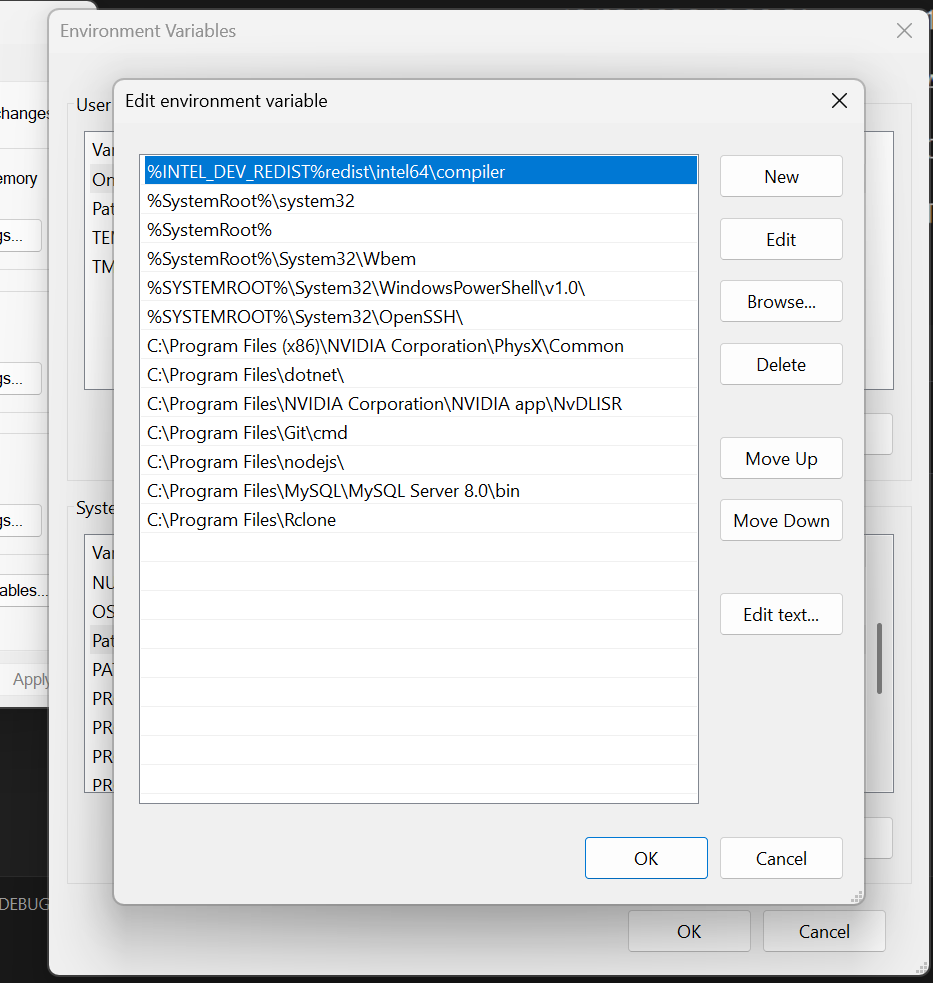

# Bước 2: Gitignore folder Backup DB


In [ ]:
# gitignore
/src/storage/DBBackup

In [ ]:
# Bước 1: Tạo ra Remote
- Nghĩa là cần cấu hình cho Rclone biết copy lên Google Drive ở đâu
> Chạy `rclone config` trên Terminal để kết nối với Google Drive (anh đặt tên remote là `gdrive`).

In [ ]:
rclone config > dbbackup_remote (Tạo remote) > 24 Google Drive (Chọn Storage)

In [ ]:
Đọc `docs` và làm theo `https://rclone.org/drive/#making-your-own-client-id`
Phần **Making your own client_id**

- Dán phần client_id và client_secret --> full access --> Bỏ qua bước `JSON file path` --> Edit advanced config --> No (default)

- Use web browser to automatically authenticate rclone with remote? (Nếu chúng ta đang chạy dòng lệnh rclone ở trên máy mà có giao diện Google Drive --> nếu chọn Yes thì sẽ bật giao diện đó lên luôn và yêu cần chúng ta xác thực. Nghĩa là nó bắt chúng ta phải login vào tài khoản mà chúng ta vừa cung cấp với Rclone để `sinh token`) --> chọn yes

- Configure this as a Shared Drive (Team Drive)? --> Yes

-> Sinh token

Keep this "dbbackup_remote" remote?

--> Yes

-> Done


Thực hiện lệnh copy: `rclone copy <thư_mục_nguồn> <tên_remote>:<thư_mục_đích>`
VD: `rclone copy src/storage/DBBackup dbbackup_remote:backupDB`

In [ ]:
const dbConfig = require("@/configs/db.config");
const { getDateStringYmdHis } = require("@/utils/dateFormat");
const { exec } = require("node:child_process");


async function backupDB() {
    const { host, user, password, port, database } = dbConfig;
    const dateStr = getDateStringYmdHis();
    const backupPath = "./src/storage/DBBackup";
    const command = `mysqldump -u${user} -p${password} -h${host} -P${port} ${database} > ${backupPath}/${database}_${dateStr}.sql`;

    /* Backup Database */
    exec(command, (error, stdout, stderr) => {
        // Lỗi thực thi câu lệnh
        if (error) return console.error(`exec error: ${error}`);
        // Lỗi trả về khi hoàn thành câu lệnh
        if (stderr) return console.error(`stderr: ${stderr}`);

        // rclone copy <thư_mục_nguồn> <tên_remote>:<thư_mục_đích>
        const command = `rclone copy ${backupPath} dbbackup_remote:backupDB`;

        // Thực thi câu lệnh thành công!
        console.log(`stdout: ${stdout}`);
    });
}

module.exports = backupDB;
